In [41]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import random
import torch
from torch import optim
import matplotlib.pyplot as plt
from torch import nn
import torch.nn.functional as F
from sklearn.metrics import precision_recall_fscore_support
from torch.utils.data import Dataset

In [56]:
# Load Fashion-MNIST
transform = transforms.ToTensor()
train_set = datasets.FashionMNIST(root='./data', train=True, download=True)

In [57]:
def unbalance_dataset(dataset, target_class=5, reduction_ratio=0.2):
    indices = list(range(len(dataset)))
    targets = dataset.targets
    class_indices = [i for i in indices if targets[i] == target_class]
    other_indices = [i for i in indices if targets[i] != target_class]
    reduced_class_indices = random.sample(
        class_indices, int(len(class_indices) * reduction_ratio)
    )
    new_indices = other_indices + reduced_class_indices
    random.shuffle(new_indices)
    return Subset(dataset, new_indices)

In [58]:
class AugmentDataset(Dataset):
    def __init__(self, dataset, target_label, augment_transform, normal_transform):
        self.dataset = dataset
        self.target = target_label
        self.augment_transform = augment_transform
        self.normal_transform = normal_transform

    def __getitem__(self, index):
        image, label = self.dataset[index]

        if label == self.target:
            image = self.augment_transform(image)
        
        else:
            image = self.normal_transform(image)

        return image, label
    

    def __len__(self):
        return len(self.dataset)

In [59]:
augment_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
])

normal_transform = transforms.ToTensor()

In [60]:
imbalanced_train = unbalance_dataset(train_set, target_class=5, reduction_ratio=0.2)

augmented_data = AugmentDataset(
    imbalanced_train,
    target_label=5,
    augment_transform=augment_transform,
    normal_transform=normal_transform
)

loader = DataLoader(augmented_data, batch_size=128, shuffle=True)


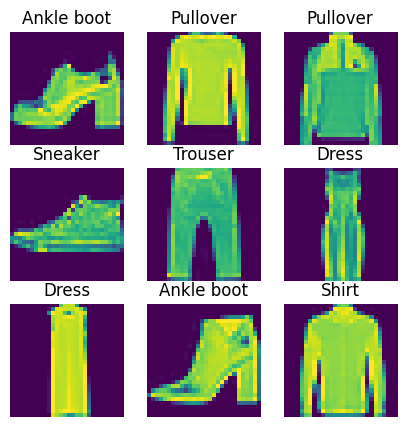

In [4]:
data_iter = iter(loader)
images, labels = next(data_iter)
classes = train_set.classes

fig = plt.figure(figsize=(5, 5))
for i in range(9):
    image, label = images[i], labels[i].item()
    plt.subplot(3, 3, i+1)
    plt.imshow(image.squeeze())
    plt.title(classes[label])
    plt.axis('off')
    
plt.show()

In [5]:
test_set = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)
test_loader = DataLoader(test_set, batch_size=128)

In [6]:
train_loader = DataLoader(train_set, batch_size=128)

In [7]:
image, label = train_set[0]
image.shape

torch.Size([1, 28, 28])

این رو مینویسم به عنوان یادگاری
که چقددد دراپ اوت و بچ نورمالیزیشن خوبه
بدون اونا مدل بدجوری داغون بود

In [8]:
class MLP(nn.Module):
    def __init__(self, input_size=28 * 28, hidden_size=256, num_classes=10, num_layers=10):
        super().__init__()
        self.input = nn.Linear(input_size, hidden_size * 2)

        self.hidden_layers = nn.ModuleList([
            nn.Linear(hidden_size * 2, hidden_size),
            nn.ReLU(),
        ])

        for _ in range(num_layers):
            self.hidden_layers.append(nn.Linear(hidden_size, hidden_size))
            self.hidden_layers.append(nn.BatchNorm1d(hidden_size))
            self.hidden_layers.append(nn.ReLU())                   
            self.hidden_layers.append(nn.Dropout(0.2))  

        self.output = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        x = x.view(x.size(0), -1)

        x = F.relu(self.input(x))

        for layer in self.hidden_layers:
            x = layer(x)

        x = self.output(x)
        return x

In [9]:
model = MLP()
optimizer = optim.Adam(model.parameters(), lr=0.0007)
criterion = nn.CrossEntropyLoss()

In [10]:
def train_model(model, optimizer, criterion, scheduler=None, epochs=10):
    losses_list = []
    val_loss_list = []
    best_val_loss = float('inf')

    for epoch in range(epochs):
        model.train()
        train_losses = 0.0
        val_losses = 0.0

        for img, label in train_loader:
            pred = model(img)
            loss = criterion(pred, label)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            if scheduler:
                scheduler.step()

            train_losses += loss.item()

        model.eval()
        with torch.no_grad():
            for img, label in test_loader:
                pred = model(img)
                val_loss = criterion(pred, label)
                val_losses += val_loss.item()

        avg_train_loss = train_losses / len(train_loader)
        avg_val_loss = val_losses / len(test_loader)
        losses_list.append(avg_train_loss)
        val_loss_list.append(avg_val_loss)

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model, './best_model_Fashion.pth')

        print(f'Epochs: {epoch + 1}, Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}')
        
    return losses_list, val_loss_list

In [13]:
train_losses, val_losses = train_model(model, optimizer, criterion, epochs=20)

Epochs: 1, Train Loss: 0.8080, Val Loss: 0.5031
Epochs: 2, Train Loss: 0.4984, Val Loss: 0.5045
Epochs: 3, Train Loss: 0.4343, Val Loss: 0.4252
Epochs: 4, Train Loss: 0.4071, Val Loss: 0.4137
Epochs: 5, Train Loss: 0.3774, Val Loss: 0.4170
Epochs: 6, Train Loss: 0.3601, Val Loss: 0.4059
Epochs: 7, Train Loss: 0.3518, Val Loss: 0.4082
Epochs: 8, Train Loss: 0.3372, Val Loss: 0.3646
Epochs: 9, Train Loss: 0.3214, Val Loss: 0.4125
Epochs: 10, Train Loss: 0.3173, Val Loss: 0.3868
Epochs: 11, Train Loss: 0.3055, Val Loss: 0.3875
Epochs: 12, Train Loss: 0.2951, Val Loss: 0.3656
Epochs: 13, Train Loss: 0.2867, Val Loss: 0.3635
Epochs: 14, Train Loss: 0.2849, Val Loss: 0.3575
Epochs: 15, Train Loss: 0.2744, Val Loss: 0.3662
Epochs: 16, Train Loss: 0.2705, Val Loss: 0.4102
Epochs: 17, Train Loss: 0.2624, Val Loss: 0.3748
Epochs: 18, Train Loss: 0.2540, Val Loss: 0.3489
Epochs: 19, Train Loss: 0.2488, Val Loss: 0.3636
Epochs: 20, Train Loss: 0.2472, Val Loss: 0.3575


In [11]:
def test_model(model):
    acc = 0.0
    with torch.no_grad():
        model.eval()
        for img, label in test_loader:
            pred = model(img)
            acc += (pred.argmax(dim=1) == label).float().mean().item()

        accuracy = acc / len(test_loader)
    
    print(f"Accuracy on test set: {accuracy*100:.2f}%")

In [15]:
test_model(model)

Accuracy on test set: 88.40%


In [ ]:
class ResidualMLP(nn.Module):
    def __init__(self, input_size=28 * 28, hidden_size=256, num_classes=10, num_layers=20):
        super().__init__()
        self.input = nn.Linear(input_size, hidden_size * 2)

        self.initial_hidden = nn.Sequential(
            nn.Linear(hidden_size * 2, hidden_size),
            nn.BatchNorm1d(hidden_size),
            nn.ReLU(),
            nn.Dropout(0.3)
        )

        self.hidden_blocks = nn.ModuleList()
        for _ in range(num_layers):
            block = nn.Sequential(
                nn.Linear(hidden_size, hidden_size),
                nn.BatchNorm1d(hidden_size),
                nn.ReLU(),
                nn.Dropout(0.25)
            )
            self.hidden_blocks.append(block)

        self.output = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = F.relu(self.input(x))
        x = self.initial_hidden(x)

        for i, block in enumerate(self.hidden_blocks):
            if i % 3 == 0:
                residual = x 
            
            x = block(x)
            
            if (i + 1) % 3 == 0:
                x = x + residual
        
        x = self.output(x)
        return x

In [13]:
model = ResidualMLP(num_layers=15)
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-3)
criterion = nn.CrossEntropyLoss()

In [14]:
residual_loss, residual_val_loss = train_model(model, optimizer, criterion, epochs=15)

Epochs: 1, Train Loss: 0.5692, Val Loss: 0.4336
Epochs: 2, Train Loss: 0.4057, Val Loss: 0.4773
Epochs: 3, Train Loss: 0.3723, Val Loss: 0.4547
Epochs: 4, Train Loss: 0.3563, Val Loss: 0.4027
Epochs: 5, Train Loss: 0.3415, Val Loss: 0.3800
Epochs: 6, Train Loss: 0.3297, Val Loss: 0.3737
Epochs: 7, Train Loss: 0.3192, Val Loss: 0.3741
Epochs: 8, Train Loss: 0.3089, Val Loss: 0.3625
Epochs: 9, Train Loss: 0.3035, Val Loss: 0.3522
Epochs: 10, Train Loss: 0.2980, Val Loss: 0.3604
Epochs: 11, Train Loss: 0.2934, Val Loss: 0.3541
Epochs: 12, Train Loss: 0.2872, Val Loss: 0.3595
Epochs: 13, Train Loss: 0.2816, Val Loss: 0.3715
Epochs: 14, Train Loss: 0.2779, Val Loss: 0.3436
Epochs: 15, Train Loss: 0.2743, Val Loss: 0.3486


In [15]:
test_model(model)

Accuracy on test set: 87.71%


In [16]:
def train_model_unbalanced(model, optimizer, criterion, scheduler=None, epochs=10):
    losses_list = []
    val_loss_list = []
    best_val_loss = float('inf')

    for epoch in range(epochs):
        model.train()
        train_losses = 0.0
        val_losses = 0.0

        for img, label in loader:
            pred = model(img)
            loss = criterion(pred, label)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            if scheduler:
                scheduler.step()

            train_losses += loss.item()

        model.eval()
        with torch.no_grad():
            for img, label in test_loader:
                pred = model(img)
                val_loss = criterion(pred, label)
                val_losses += val_loss.item()

        avg_train_loss = train_losses / len(loader)
        avg_val_loss = val_losses / len(test_loader)
        losses_list.append(avg_train_loss)
        val_loss_list.append(avg_val_loss)

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model, './best_model_Fashion.pth')

        print(f'Epochs: {epoch + 1}, Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}')
        
    return losses_list, val_loss_list

In [30]:
t = torch.ones(10)
t[4] = 3

In [51]:
model = ResidualMLP()
optimizer = optim.Adam(model.parameters(), lr=0.0001)
criterion = nn.CrossEntropyLoss(weight=t)

In [62]:
losses_list, val_loss_list = train_model_unbalanced(model, optimizer, criterion, epochs=5)

Epochs: 1, Train Loss: 0.3829, Val Loss: 0.4227
Epochs: 2, Train Loss: 0.3638, Val Loss: 0.4309
Epochs: 3, Train Loss: 0.3482, Val Loss: 0.4475
Epochs: 4, Train Loss: 0.3357, Val Loss: 0.4249
Epochs: 5, Train Loss: 0.3240, Val Loss: 0.4005


In [63]:
def test_model_unbalanced(model):
    all_labels = []
    all_preds = []
    with torch.no_grad():
        model.eval()
        for img, label in test_loader:
            pred = model(img)
            pred = pred.argmax(dim=1)

            all_preds.extend(pred.numpy())
            all_labels.extend(label.numpy())

    precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='weighted')
    
    print(f"Precision on test set: {precision*100:.2f}%")
    print(f"Recall on test set: {recall*100:.2f}%")    
    print(f"F1 Score on test set: {f1*100:.2f}%")

In [64]:
test_model_unbalanced(model)

Precision on test set: 86.62%
Recall on test set: 85.76%
F1 Score on test set: 85.79%


In [26]:
test_model_unbalanced(model)

Precision on test set: 88.96%
Recall on test set: 88.77%
F1 Score on test set: 88.77%
